In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import LinearNDInterpolator, RBFInterpolator

sys.path.append('C:\\Users\\Mark\\PycharmProjects\\approximationMap')
from control.experiment_data import ExperimentData
from control.database import DatabaseHandler

# Исходные данные

In [2]:
db = DatabaseHandler()
df = db.get_all_experiment_data()

diesel_air = df.loc[(df['fuel_id'] == 1) & (df['F_air'].notna())]
diesel_steam = df.loc[(df['fuel_id'] == 1) & (df['F_steam'].notna())]

crude_oil_steam = df.loc[(df['fuel_id'] == 2) & (df['F_steam'].notna())]

heavy_oil_air = df.loc[(df['fuel_id'] == 3) & (df['F_air'].notna())]
heavy_oil_steam = df.loc[(df['fuel_id'] == 3) & (df['F_steam'].notna())]

kerosene_air = df.loc[(df['fuel_id'] == 4) & (df['F_air'].notna())]
kerosene_steam = df.loc[(df['fuel_id'] == 4) & (df['F_steam'].notna())]

waste_oil_steam = df.loc[(df['fuel_id'] == 5) & (df['F_steam'].notna())]

dfs = {
    'diesel_air': diesel_air, 
    'diesel_steam': diesel_steam, 
    'crude_oil_steam': crude_oil_steam, 
    'heavy_oil_air': heavy_oil_air, 
    'heavy_oil_steam': heavy_oil_steam, 
    'kerosene_air': kerosene_air, 
    'kerosene_steam': kerosene_steam, 
    'waste_oil_steam': waste_oil_steam
}

# Суммарное значение воздуха

In [3]:
sum_air_coef = {
    'diesel': 14.431,
    'crude_oil': 13.775,
    'heavy_oil': 13.660,
    'kerosene': 14.523,
    'waste_oil': 14.408
}

for key in dfs:
    if key.count('_') == 1:
        fuel_type = key.split('_')[0]
        dfs[key] = dfs[key].copy()
        dfs[key].loc[:, 'sum_air'] = dfs[key]['F_fuel'] * sum_air_coef[fuel_type] * 21 / (21 - dfs[key]['O2'])
    else:
        fuel_type = key.split('_')[0] + '_' + key.split('_')[1]
        dfs[key] = dfs[key].copy()
        dfs[key].loc[:, 'sum_air'] = dfs[key]['F_fuel'] * sum_air_coef[fuel_type] * 21 / (21 - dfs[key]['O2'])


# Импульс струи

## Расчет струи

In [4]:
steam_params = pd.DataFrame({
    "Cp": [2.139108184, 2.079572787],  # теплоемкость (Дж/(кг*К)) Cp
    "adiabat": [1.302022264, None],  # показатель адиабаты kg
    "mol_mass": [0.018, None],  # молярная масса (кг/моль)
    "G": [0.000222222, None],  # mass flowrate (kg/s) G
    "G_hr": [0.8, None],  # mass flowrate (кг/ч) G_hr
    "D_tube": [0.003, None],  # диаметр отверстия трубки
    "D_jet": [0.0006, None],  # диаметр отверстия форсунки
    "P": [7.4, 1.01],  # P (bar)
    "T": [523.15, 329.6083348],  # T (K)
    "t": [250, 56.60833484],  # t_C (C)
    "rho": [3.063916824, 0.663734924],  # rho (kg/m3)
    "U": [10.26072679, 931.3243951],  # U (m/s)
    "Q": [4.351728228, 20.08834076],  # Q (л/мин)
    "Y_jet": [0.002280162, 0.207]  # Yjet (N)
}, index=["input_tube", "jet"]
)

air_params = pd.DataFrame({
    "Cp": [1.006, 1.006],  # теплоемкость (Дж/(кг*К)) Cp
    "adiabat": [1.4, None],  # показатель адиабаты kg
    "mol_mass": [0.029, None],  # молярная масса (кг/моль)
    "G": [0.000287778, None],  # mass flowrate (kg/s) G
    "G_hr": [1.036, None],  # mass flowrate (кг/ч) G_hr
    "D_tube": [0.003, None],  # диаметр отверстия трубки
    "D_jet": [0.0006, None],  # диаметр отверстия форсунки
    "P": [7.8, 1.01],  # P (bar)
    "T": [523.15, 291.7270737],  # T (K)
    "t": [250, 18.72707372],  # t_C (C)
    "rho": [5.20313803, 1.208207736],  # rho (kg/m3)
    "U": [7.824552641, 682.4105445],  # U (m/s)
    "Q": [3.318510208, 14.29114063],  # Q (л/мин)
    "Y_jet": [0.002251732, 0.196]  # Yjet (N)
}, index=["input_tube", "jet"])


## Струя выбросы

In [5]:
for key in dfs:
    st_prm_tube = steam_params.loc['input_tube']
    st_prm_jet = steam_params.loc['jet']

    air_prm_tube = air_params.loc['input_tube']
    air_prm_jet = air_params.loc['jet']
    
    if 'steam' in key:
        dfs[key] = dfs[key].copy()
        
        P_abs = 7.8 * dfs[key]['F_steam']
        ro_tube = P_abs * 100_000 * st_prm_tube['mol_mass'] / st_prm_tube['T'] / 8.31
        ro_atm = ((st_prm_jet['P'] / P_abs) ** (1 / st_prm_tube['adiabat'])) * ro_tube
        T_atm = st_prm_jet['P'] * 100_000 / ro_atm / 8.31 * st_prm_tube['mol_mass']
        U_tube = dfs[key]['F_steam'] / 3_600 / np.pi / ro_tube / st_prm_tube['D_tube'] / st_prm_tube['D_tube'] * 4
        U_atm = np.sqrt(-2 * st_prm_jet['Cp'] * 1_000 * T_atm + U_tube * U_tube + 2 * st_prm_tube['Cp'] * 1_000 * st_prm_tube['T'])
        dfs[key].loc[:, 'J'] = U_atm * dfs[key]['F_steam'] / 3_600
        
    else:
        dfs[key] = dfs[key].copy()
        
        P_abs = 7.8 * dfs[key]['F_air']
        ro_tube = P_abs * 100_000 * air_prm_tube['mol_mass'] / air_prm_tube['T'] / 8.31
        ro_atm = ((air_prm_jet['P'] / P_abs) ** (1 / air_prm_tube['adiabat'])) * ro_tube
        T_atm = air_prm_jet['P'] * 100_000 / ro_atm / 8.31 * air_prm_tube['mol_mass']
        U_tube = dfs[key]['F_air'] / 3_600 / np.pi / ro_tube / air_prm_tube['D_tube'] / air_prm_tube['D_tube'] * 4
        U_atm = np.sqrt(-2 * air_prm_jet['Cp'] * 1_000 * T_atm + U_tube * U_tube + 2 * air_prm_tube['Cp'] * 1_000 * air_prm_tube['T'])
        dfs[key].loc[:, 'J'] = U_atm * dfs[key]['F_air'] / 3_600
        

# Построение графиков

In [6]:
dfs['diesel_steam'] = dfs['diesel_steam'].round(3)
pivoted = dfs['diesel_steam'].pivot_table(index='J', values='sum_air', columns='F_fuel')

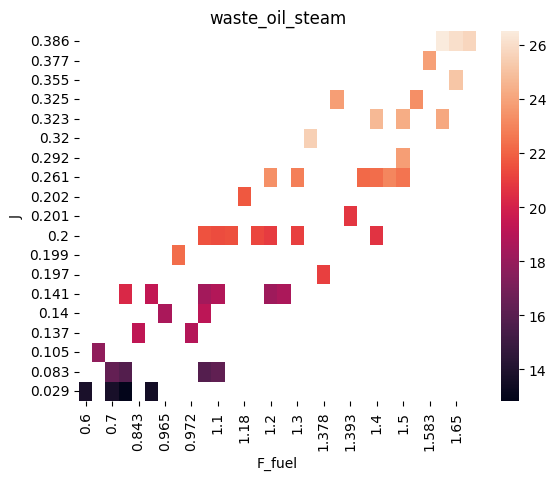

In [7]:
ax = sns.heatmap(data=pivoted)

ax.set_title('waste_oil_steam')

ax.invert_yaxis()

    F_fuel         J    sum_air
1      0.8  0.059610  14.552269
2      0.9  0.059610  14.302354
4      0.8  0.087433  16.436664
5      0.9  0.087433  16.148366
6      1.0  0.087433  15.983703
8      0.8  0.114542  18.663649
9      1.0  0.114542  18.146766
10     1.1  0.114542  17.960997
12     0.8  0.143509  20.563257
13     1.0  0.143509  19.704226
14     1.1  0.143509  19.830821
15     1.2  0.143509  19.604377
17     0.9  0.170068  21.646500
18     1.0  0.170068  21.074478
19     1.2  0.170068  21.279181
20     1.3  0.170068  21.124198
22     0.9  0.197707  23.251995
23     1.0  0.197707  22.481528
24     1.2  0.197707  22.420543
25     1.3  0.197707  22.095698
26     1.4  0.197707  21.982974
28     0.7  0.032489  12.333471
29     0.6  0.032489  12.319146
30     0.5  0.032489  12.722544
32     0.7  0.059610  14.266019
33     0.6  0.059610  14.770967
34     0.5  0.059610  15.557033
35     0.7  0.087433  16.457386
36     0.6  0.087433  17.170028
37     0.7  0.114542  18.856507
F_fuel  

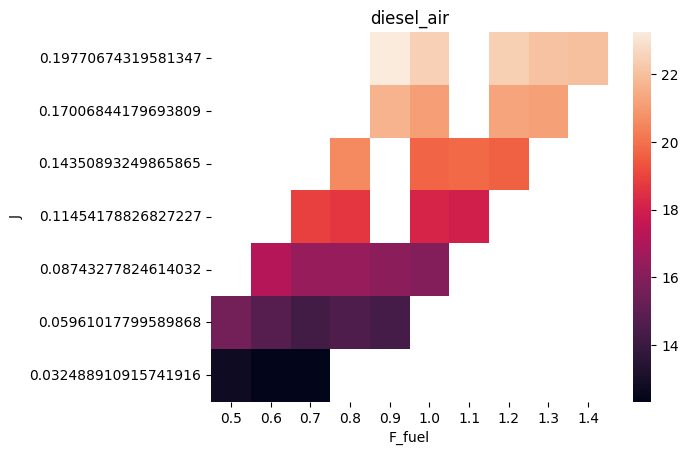

     F_fuel      J  sum_air
46    0.600  0.029   13.765
47    0.700  0.029   13.695
48    0.800  0.029   12.834
49    0.900  0.029   13.516
52    0.700  0.083   16.356
53    0.800  0.083   15.804
54    1.000  0.083   15.867
55    1.100  0.083   16.214
58    0.800  0.141   20.254
59    0.900  0.141   19.357
60    1.000  0.141   18.344
61    1.100  0.141   18.834
62    1.200  0.141   18.201
63    1.250  0.141   18.615
65    1.100  0.200   21.383
66    1.000  0.200   21.554
67    1.200  0.200   20.900
68    1.400  0.200   20.676
69    1.300  0.200   21.034
72    1.200  0.261   23.387
73    1.300  0.261   22.839
74    1.400  0.261   22.318
75    1.500  0.261   22.515
77    1.500  0.292   23.775
79    1.400  0.323   24.710
80    1.500  0.323   24.257
81    1.600  0.323   24.123
85    1.650  0.355   25.115
87    1.600  0.386   26.496
88    1.650  0.386   26.043
89    1.700  0.386   25.721
92    0.965  0.140   18.559
93    1.180  0.202   21.699
94    1.377  0.320   25.524
95    1.378  0.197  

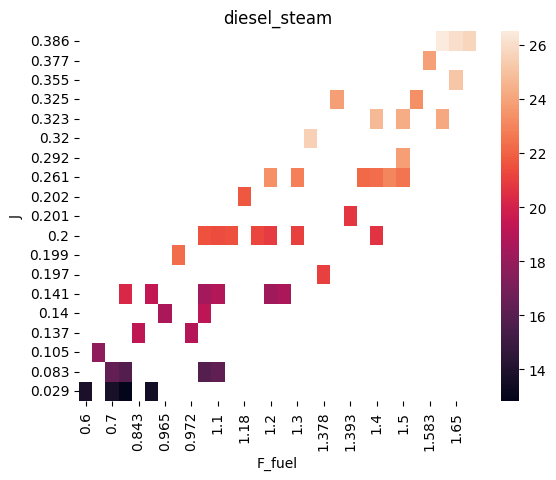

     F_fuel         J    sum_air
111     1.0  0.140800  14.804248
112     0.8  0.140800  15.678862
113     0.7  0.140800  16.109189
116     0.9  0.083395  13.056545
117     0.8  0.083395  13.415652
118     0.7  0.083395  14.081537
123     0.8  0.028929  11.953512
124     1.0  0.200259  17.542450
125     0.9  0.200259  18.373147
126     0.8  0.200259  18.891429
127     1.1  0.200259  17.350191
128     1.2  0.200259  17.227295
131     1.0  0.261177  19.414430
132     0.9  0.261177  20.181977
133     1.1  0.261177  19.426282
134     1.2  0.261177  19.220930
135     1.3  0.261177  19.454604
138     1.3  0.323200  22.424419
139     1.4  0.323200  20.940279
140     1.2  0.323200  23.219398
141     1.1  0.323200  22.615672
142     1.0  0.323200  22.634977
145     1.5  0.386103  22.161006
146     1.4  0.386103  22.424419
147     1.3  0.386103  23.357609
148     1.2  0.386103  23.203877
149     1.1  0.386103  23.961032
F_fuel          0.7        0.8        0.9        1.0        1.1        1.2  

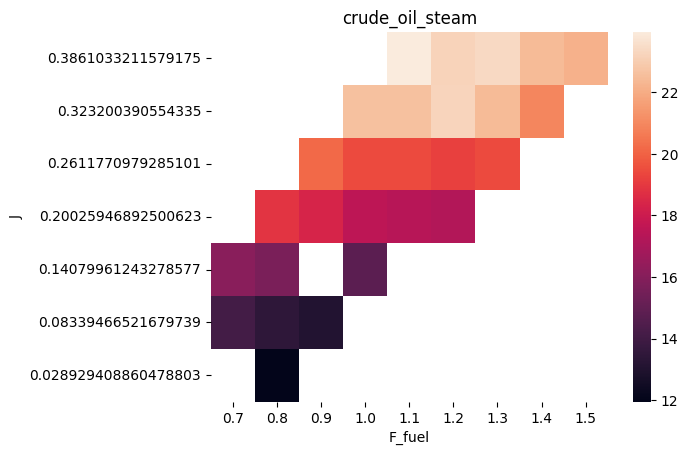

     F_fuel         J    sum_air
199    0.83  0.143509  16.767169
200    0.70  0.143509  17.162564
201    0.60  0.143509  16.940551
203    0.93  0.143509  15.358653
205    1.00  0.197707  17.374924
206    0.93  0.197707  18.787310
207    0.80  0.197707  19.647945
208    0.90  0.197707  18.762645
209    0.70  0.197707  19.015341
212    0.55  0.071769  11.449419
213    0.60  0.071769  11.104258
214    0.65  0.071769  10.981095
215    0.68  0.071769  10.867120
217    0.50  0.071769  11.972454
F_fuel         0.50       0.55       0.60       0.65      0.68       0.70  \
J                                                                           
0.071769  11.972454  11.449419  11.104258  10.981095  10.86712        NaN   
0.143509        NaN        NaN  16.940551        NaN       NaN  17.162564   
0.197707        NaN        NaN        NaN        NaN       NaN  19.015341   

F_fuel         0.80       0.83       0.90       0.93       1.00  
J                                                    

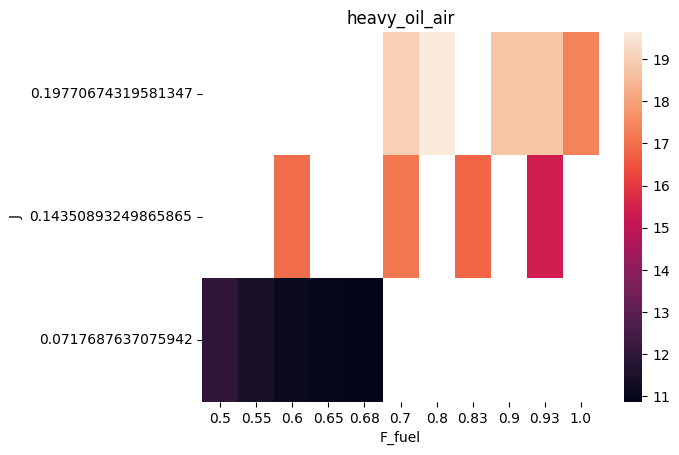

     F_fuel         J    sum_air
153    0.50  0.140800  13.831244
154    0.80  0.140800  15.936667
155    0.83  0.140800  16.076556
156    0.90  0.140800  16.055597
157    0.95  0.140800  15.825610
158    1.02  0.140800  15.247379
161    0.80  0.261177  18.919044
162    0.85  0.261177  18.857773
163    0.90  0.261177  18.983382
164    0.93  0.261177  19.082961
165    1.05  0.261177  19.063481
166    1.08  0.261177  18.925400
167    1.10  0.261177  18.324390
169    0.95  0.386103  21.141738
170    1.10  0.386103  21.867360
171    1.30  0.386103  22.669787
172    1.35  0.386103  22.780059
174    0.60  0.140800  17.689209
175    0.65  0.140800  17.409804
176    0.73  0.140800  15.386319
177    0.80  0.140800  15.947741
178    0.88  0.140800  16.171480
179    0.93  0.140800  15.209795
180    0.95  0.140800  14.738615
183    0.65  0.261177  16.920054
184    0.70  0.261177  17.104089
185    0.80  0.261177  17.845101
186    0.90  0.261177  17.408901
187    1.00  0.261177  17.105546
188    1.1

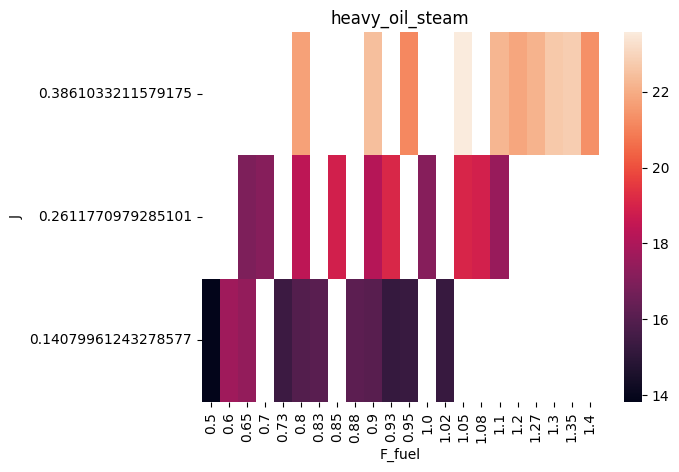

     F_fuel         J    sum_air
236    0.99  0.136458  23.459055
237    1.11  0.136458  24.640046
238    1.32  0.136458  24.582637
239    1.44  0.136458  24.087923
240    0.90  0.082747  23.424709
241    0.99  0.082747  23.116071
242    1.11  0.082747  23.480177
243    1.32  0.082747  23.593286
244    1.41  0.082747  23.598108
245    1.05  0.196276  26.769487
246    1.11  0.196276  26.757942
247    1.32  0.196276  26.591461
248    1.50  0.196276  25.825104
F_fuel         0.90       0.99       1.05       1.11       1.32       1.41  \
J                                                                            
0.082747  23.424709  23.116071        NaN  23.480177  23.593286  23.598108   
0.136458        NaN  23.459055        NaN  24.640046  24.582637        NaN   
0.196276        NaN        NaN  26.769487  26.757942  26.591461        NaN   

F_fuel         1.44       1.50  
J                               
0.082747        NaN        NaN  
0.136458  24.087923        NaN  
0.196276       

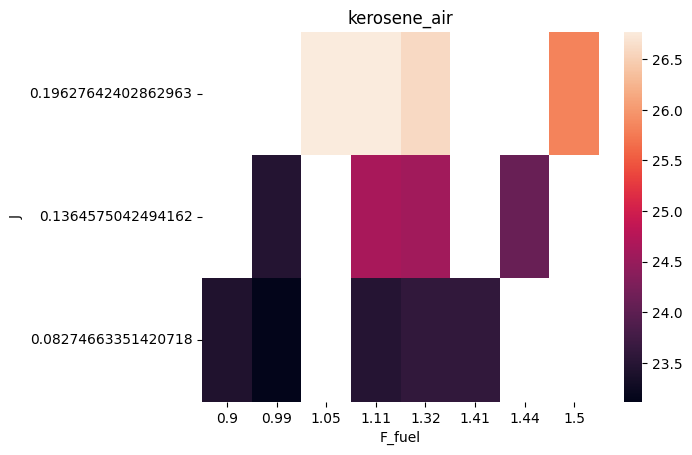

     F_fuel         J    sum_air
218    0.99  0.140800  24.459253
219    1.11  0.140800  24.776916
220    1.32  0.140800  24.761559
221    1.44  0.140800  24.168591
222    0.90  0.083395  23.297718
223    0.99  0.083395  22.992565
224    1.11  0.083395  23.638845
225    1.32  0.083395  23.574122
226    1.41  0.083395  23.023541
227    1.05  0.200259  26.224268
228    1.11  0.200259  26.349134
229    1.32  0.200259  25.682506
230    1.50  0.200259  24.832828
231    1.26  0.323200  30.236652
232    1.32  0.323200  30.127038
233    1.41  0.323200  29.950812
234    1.50  0.323200  28.537459
235    1.65  0.323200  26.941403
F_fuel         0.90       0.99       1.05       1.11       1.26       1.32  \
J                                                                            
0.083395  23.297718  22.992565        NaN  23.638845        NaN  23.574122   
0.140800        NaN  24.459253        NaN  24.776916        NaN  24.761559   
0.200259        NaN        NaN  26.224268  26.349134        N

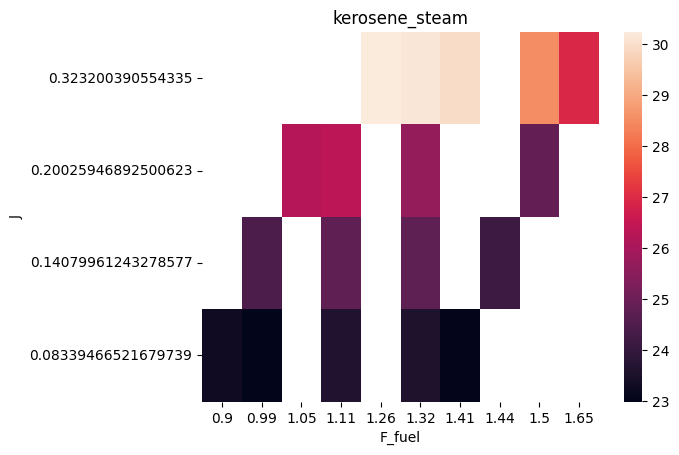

       F_fuel         J    sum_air
249  0.405143  0.209315   8.456782
250  0.531718  0.251463   9.908158
251  0.598068  0.313665   9.659324
253  0.495263  0.207240  10.856672
254  0.597948  0.264717  10.672618
255  0.704752  0.305058  11.080075
F_fuel    0.405143   0.495263  0.531718   0.597948  0.598068   0.704752
J                                                                      
0.207240       NaN  10.856672       NaN        NaN       NaN        NaN
0.209315  8.456782        NaN       NaN        NaN       NaN        NaN
0.251463       NaN        NaN  9.908158        NaN       NaN        NaN
0.264717       NaN        NaN       NaN  10.672618       NaN        NaN
0.305058       NaN        NaN       NaN        NaN       NaN  11.080075
0.313665       NaN        NaN       NaN        NaN  9.659324        NaN


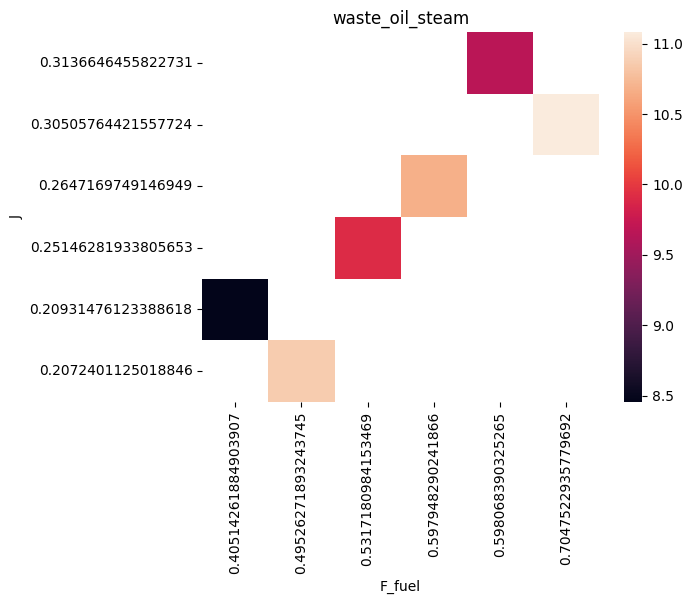

In [8]:
for key in dfs:
    #dfs[key] = dfs[key].round(3)
    dfs[key] = dfs[key].dropna(subset=['sum_air'])
    print(dfs[key][['F_fuel', 'J', 'sum_air']])
    pivoted = dfs[key].pivot_table(index='J', values='sum_air', columns='F_fuel')
    print(pivoted)
    
    ax = sns.heatmap(data=pivoted)
    ax.set_title(key)
    ax.invert_yaxis()
    
    plt.show()
    plt.close()
    

# Разбор ошибок

Почему нет значений расхода топлива > 0.7 у waste_oil?

Потому что отсутствуют значения кислорода по газовому анализу для данного расхода топлива

In [9]:
dfs['waste_oil_steam'][['F_fuel', 'O2']].loc[dfs['waste_oil_steam']['F_fuel'] > 0.71]

,F_fuel,O2


In [10]:
dfs['kerosene_steam'].loc[dfs['kerosene_steam']['sum_air'].notna()]

,experiment_id,fuel_id,F_fuel,F_air,F_steam,O2,CO,NO,NO2,NOx,CO2,SO2,P_air,P_steam,comments,t_wg,sum_air,J
218,2374,4,0.99,NaN,0.6,8.655667,56.470000,22.640000,3.580000,26.220000,9.630333,3.633333,NaN,4.5,None,24.993333,24.459253,0.140800
219,2375,4,1.11,NaN,0.6,7.336833,29.075000,27.613333,2.931667,30.545000,10.640000,3.766667,NaN,4.5,None,24.491667,24.776916,0.140800
220,2376,4,1.32,NaN,0.6,4.741833,16.386667,41.320000,2.060000,43.380000,12.571167,6.450000,NaN,4.5,None,25.101667,24.761559,0.140800
221,2377,4,1.44,NaN,0.6,2.828667,21.133333,46.868333,2.170000,49.038333,14.064000,8.650000,NaN,4.5,None,25.700000,24.168591,0.140800
222,2378,4,0.90,NaN,0.4,9.218387,64.396774,25.590323,4.977419,30.567742,9.226774,2.645161,NaN,2.8,None,24.925806,23.297718,0.083395
223,2379,4,0.99,NaN,0.4,7.868226,35.796774,37.635484,3.150000,40.785484,10.222419,4.354839,NaN,2.8,None,25.232258,22.992565,0.083395
224,2380,4,1.11,NaN,0.4,6.679032,26.612903,43.772581,2.796774,46.569355,11.107742,5.000000,NaN,2.8,None,25.200000,23.638845,0.083395
225,2381,4,1.32,NaN,0.4,3.922903,23.750000,61.825806,2.372581,64.198387,13.195161,7.016129,NaN,2.8,None,25.733871,23.574122,0.083395
226,2382,4,1.41,NaN,0.4,2.322333,31.266667,68.250000,2.556667,70.806667,14.457333,8.766667,NaN,2.8,None,26.000000,23.023541,0.083395
227,2383,4,1.05,NaN,0.8,8.788710,45.019355,15.354839,2.351613,17.706452,9.430645,3.000000,NaN,6.5,None,25.829032,26.224268,0.200259


In [11]:
dfs['kerosene_steam'].pivot_table(index='J', values='sum_air', columns='F_fuel')

F_fuel,0.90,0.99,1.05,1.11,1.26,1.32,1.41,1.44,1.50,1.65
J,,,,,,,,,,
0.083395,23.297718,22.992565,NaN,23.638845,NaN,23.574122,23.023541,NaN,NaN,NaN
0.140800,NaN,24.459253,NaN,24.776916,NaN,24.761559,NaN,24.168591,NaN,NaN
0.200259,NaN,NaN,26.224268,26.349134,NaN,25.682506,NaN,NaN,24.832828,NaN
0.323200,NaN,NaN,NaN,NaN,30.236652,30.127038,29.950812,NaN,28.537459,26.941403


## Интерполированная поверхность

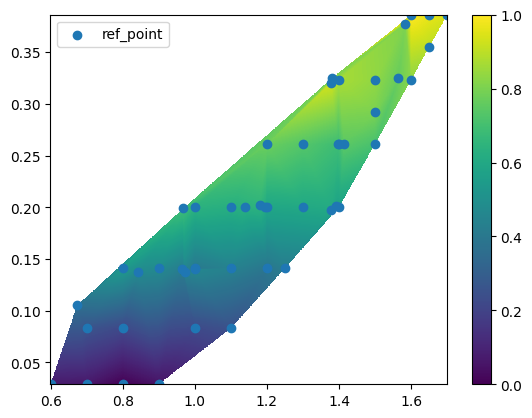

In [12]:
dfs['diesel_steam'] = dfs['diesel_steam'].dropna(subset=['sum_air'])

x = np.array(dfs['diesel_steam']['F_fuel'])
y = np.array(dfs['diesel_steam']['J'])
z = np.array(dfs['diesel_steam']['sum_air'])


X = np.linspace(dfs['diesel_steam']['F_fuel'].min(), dfs['diesel_steam']['F_fuel'].max(), 1_000)
Y = np.linspace(dfs['diesel_steam']['J'].min(), dfs['diesel_steam']['J'].max(), 1_000)
X, Y = np.meshgrid(X, Y)

interp = LinearNDInterpolator(list(zip(x, y)), z)
Z = interp(X, Y)

plt.pcolormesh(X, Y, Z)
plt.scatter(x, y, label='ref_point')
plt.legend()
plt.colorbar()

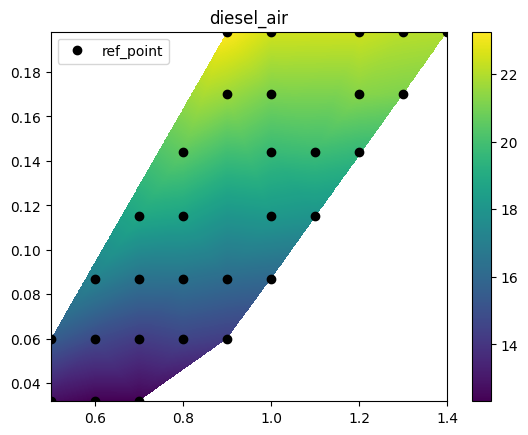

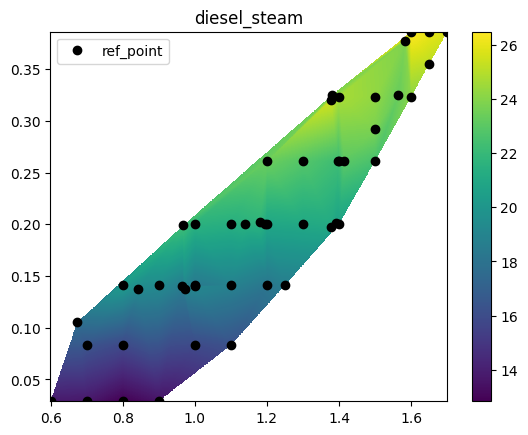

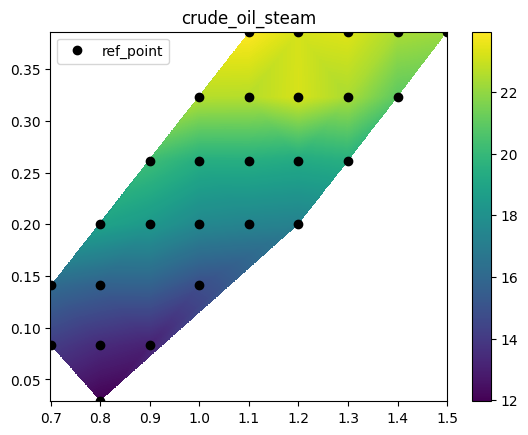

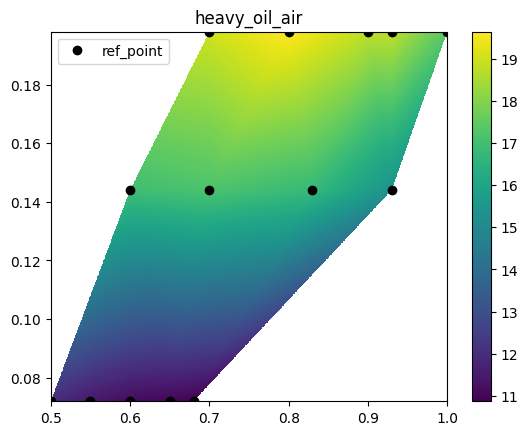

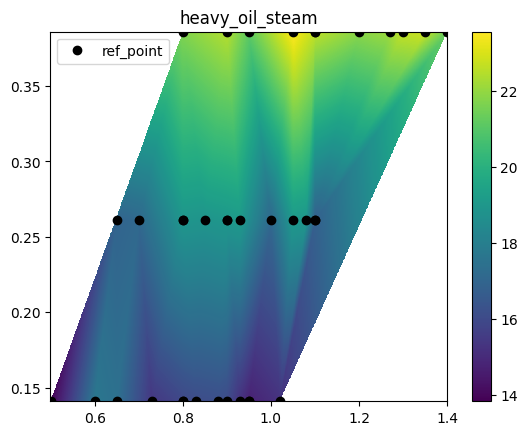

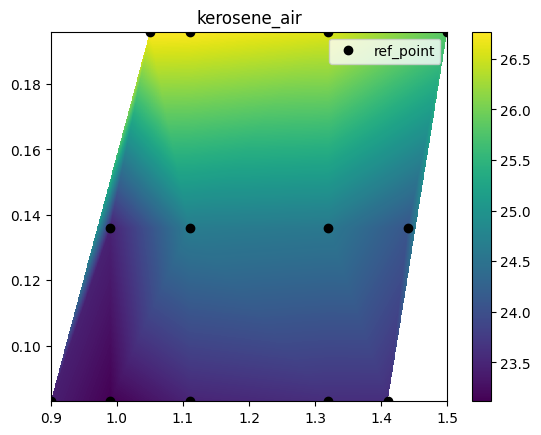

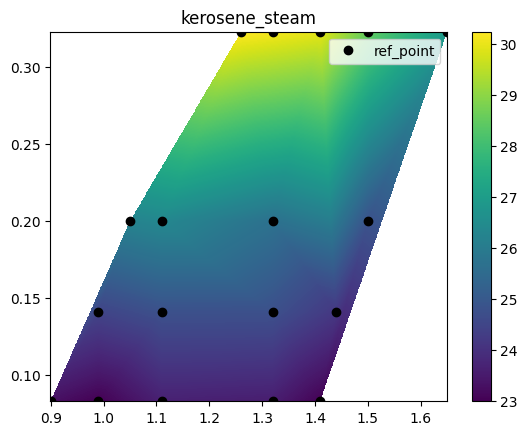

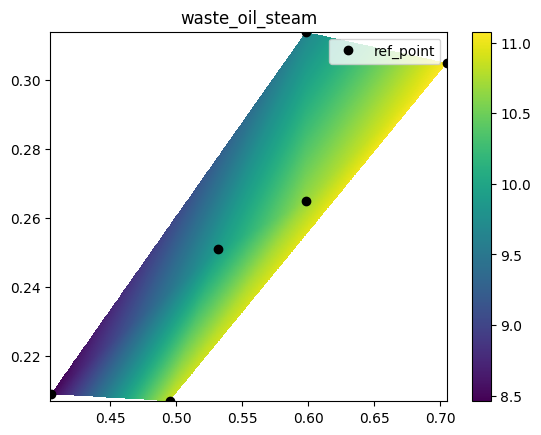

In [13]:
for key in dfs:
    dfs[key] = dfs[key].round(3)
    dfs[key] = dfs[key].dropna(subset=['sum_air'])
    
    x = np.array(dfs[key]['F_fuel'])
    y = np.array(dfs[key]['J'])
    z = np.array(dfs[key]['sum_air'])

    X = np.linspace(x.min(), x.max(), 1_000)
    Y = np.linspace(y.min(), y.max(), 1_000)
    X, Y = np.meshgrid(X, Y)

    interp = LinearNDInterpolator(list(zip(x, y)), z)
    Z = interp(X, Y)
    
    plt.pcolormesh(X, Y, Z, shading='auto')
    plt.plot(x, y, 'ok', label='ref_point')
    plt.legend()
    plt.colorbar()
   
    plt.title(key)
    
    plt.show()
    plt.close()